# Week 9: Diffusion Models as Score-Based Models
### Author: Rajit Rajpal
The goal of this tutorial will be to learn about diffusion models from a denoising score matching perspective and how to condition it. `# TODO` are for you to implement. Solutions will contain the completed code. 

The MNIST portion of the tutorial is difficult to get good results without a much larger model which is not CPU-friendly to train. If you have access to a GPU (maybe Google Colab), by all means use it. Increase the number of epochs and the size of the model! If not, try to play around more with the first half of the code which is more focused on 2D problems.
### Imports

In [29]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms

# Set random seed for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Data and Setup

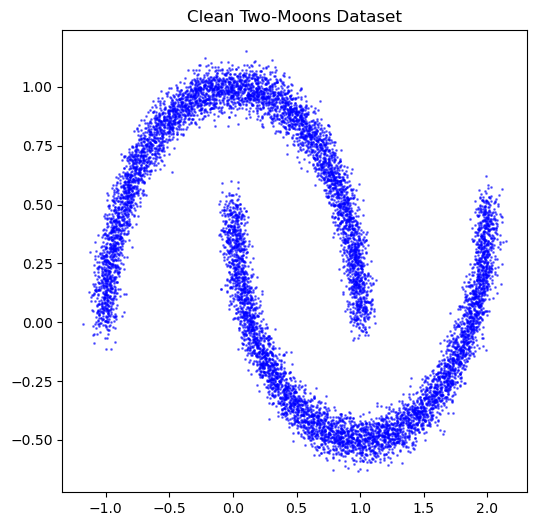

In [30]:
# Generate Two-Moons dataset
X_moons, _ = make_moons(n_samples=10000, noise=0.05, random_state=SEED)
X_moons = torch.tensor(X_moons, dtype=torch.float32)

plt.figure(figsize=(6, 6))
plt.scatter(X_moons[:, 0], X_moons[:, 1], s=1, alpha=0.5, color='blue')
plt.title("Clean Two-Moons Dataset")
plt.show()

In [ ]:
# Variance-Preserving Noise Schedule
num_steps = 100
betas = torch.linspace(1e-4, 0.02, num_steps).to(device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

def q_sample(x_0, t, noise=None):
    """Samples z_t from q(z_t | x_0)"""
    if noise is None:
        noise = torch.randn_like(x_0)
        
    # Get the alpha values for the batch
    alpha_cumprod_t = alphas_cumprod[t]
    
    # Dynamically reshape alpha_cumprod_t to match the dimensions of x_0
    # For 2D data: (-1, 1)
    # For 4D images: (-1, 1, 1, 1)
    reshape_dims = (-1,) + (1,) * (x_0.dim() - 1)
    alpha_cumprod_t = alpha_cumprod_t.view(*reshape_dims)
    
    return torch.sqrt(alpha_cumprod_t) * ... + torch.sqrt(1 - alpha_cumprod_t) * noise  # TODO

# Simple MLP Model for 2D Data
class ToyMLP(nn.Module):
    def __init__(self, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2 + 1, hidden_dim), # +1 for time embedding
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, 2)
        )
        
    def forward(self, x, t):
        # Normalize t between 0 and 1
        t_norm = (t.float() / num_steps).view(-1, 1)
        x_input = torch.cat([x, t_norm], dim=1)
        return self.net(x_input) # We will train this to predict epsilon

### How are Score, $\epsilon$, $x_0$, and $v$ related?

As shown in the lecture, the score of the marginal noised distribution $p_n(z_n)$ can be expressed exactly as:$$\nabla_{z} \log p(z_n) = \frac{1}{V_n}(\mathbb{E}[z_0|z_n] - z_n)$$where $V_n$ is the accumulated variance at step $n$.This means that to estimate the score, we just need to estimate the original clean data point $z_0$ (also called $x_0$) from the noisy point $z_n$.We can parameterize our neural network to predict different targets, and they are all mathematically equivalent to predicting the score:

$x_0$-prediction: The network predicts the clean data $\hat{x}_0$. The score is then estimated as $\frac{\hat{x}_0 - z_n}{V_n}$.

$\epsilon$-prediction: Since $z_n = x_0 + \sqrt{V_n}\epsilon$, predicting the noise $\hat{\epsilon}$ allows us to recover $x_0$. 
The score is simply $-\frac{\hat{\epsilon}}{\sqrt{V_n}}$.

v-prediction: The network predicts $v = \sqrt{\bar{\alpha}_n} \epsilon - \sqrt{1 - \bar{\alpha}_n} x_0$ (where $\bar{\alpha}$ represents the signal ratio). This is a velocity vector that interpolates between the data and the noise, offering better numerical stability for certain noise schedules.

In [ ]:
@torch.no_grad()
def sample_trajectory(model, param_type, num_samples=1000):
    model.eval()
    z = torch.randn(num_samples, 2).to(device)
    
    # We will save snapshots at t=100 (noise), 75, 50, 25, and 0 (data)
    snapshots = [z.cpu().numpy()]
    save_steps = [75, 50, 25, 0]
    
    for i in reversed(range(num_steps)):
        t = torch.full((num_samples,), i, device=device, dtype=torch.long)
        pred = model(z, t)
        
        alpha_t = alphas[t].view(-1, 1)
        alpha_cumprod_t = alphas_cumprod[t].view(-1, 1)
        beta_t = betas[t].view(-1, 1)
        
        if param_type == "eps":
            eps_pred = pred
        elif param_type == "x0":
            x0_pred = pred
            eps_pred = (z - torch.sqrt(alpha_cumprod_t) * ...) / torch.sqrt(1 - alpha_cumprod_t) # TODO
        elif param_type == "v":
            v_pred = pred
            eps_pred = torch.sqrt(1 - alpha_cumprod_t) * ... + torch.sqrt(alpha_cumprod_t) * v_pred # TODO
        elif param_type.startswith("score"): # Catches both 'score_weighted' and 'score_unweighted'
            score_pred = pred
            # score = -eps / sqrt(V_t) -> eps = -score * sqrt(V_t)
            eps_pred = -score_pred * torch.sqrt(1 - alpha_cumprod_t)
        else:
            raise ValueError(f"Unknown parameterization type passed to function: {param_type}")
            
        # Add Langevin noise if not at the final step
        noise = torch.randn_like(z) if i > 0 else torch.zeros_like(z)
            
        # Standard Reverse DDPM step
        z = (1 / torch.sqrt(alpha_t)) * (z - (beta_t / torch.sqrt(1 - alpha_cumprod_t)) * eps_pred) + torch.sqrt(beta_t) * noise
        
        if i in save_steps:
            snapshots.append(z.cpu().numpy())
            
    return snapshots

### The Problem with Direct Score Prediction

From the slides, we know the score relates to the added noise $\epsilon$ like this:$$\nabla_{z} \log p(z_t) \approx -\frac{\epsilon}{\sqrt{V_t}}$$. Notice the $\sqrt{V_t}$ (the standard deviation of the noise at time $t$) in the denominator.At $t=100$, the noise variance $V_t$ is large, so the score vectors are relatively small. At $t=1$, the noise variance $V_t$ is incredibly tiny (approaching zero). This causes the true score values to explode toward infinity. Neural networks hate predicting targets whose magnitudes vary wildly. If you force a network to directly predict the score, it will struggle to balance the massive gradients near $t=0$ with the tiny gradients near $t=100$. Why $\epsilon$-Prediction WinsBy training the network to predict the noise $\epsilon$ instead, the target is always drawn from a standard normal distribution $\mathcal{N}(0, I)$. This means the target has a variance of 1 across all timesteps, making the optimization landscape incredibly smooth and stable. Once the network predicts $\epsilon$, we simply calculate the score after the fact by dividing by $-\sqrt{V_t}$.

In [ ]:
models = {
    "eps": ToyMLP().to(device),
    "x0": ToyMLP().to(device),
    "v": ToyMLP().to(device),
    "score_weighted": ToyMLP().to(device),
    "score_unweighted": ToyMLP().to(device),
}

optimizers = {name: torch.optim.Adam(model.parameters(), lr=1e-3) for name, model in models.items()}

dataloader_2d = DataLoader(TensorDataset(X_moons), batch_size=256, shuffle=True)
epochs = 100

print(f"Training {len(models)} models...")
for epoch in range(epochs):
    for batch in dataloader_2d:
        x_0 = batch[0].to(device)
        batch_size = x_0.shape[0]
        
        # Sample random time steps and noise
        t = torch.randint(0, num_steps, (batch_size,), device=device).long()
        noise = torch.randn_like(x_0)
        z_t = q_sample(x_0, t, noise)
        
        # Get alpha values for the targets
        alpha_cumprod_t = alphas_cumprod[t].view(-1, 1)
        sqrt_alpha_cumprod_t = torch.sqrt(alpha_cumprod_t)
        sqrt_one_minus_alpha_cumprod_t = torch.sqrt(1 - alpha_cumprod_t)
        V_t = 1.0 - alpha_cumprod_t # Variance at time t
        
        # Define Targets for each parameterization
        targets = {
            "eps": noise,
            "x0": x_0,
            "v": sqrt_alpha_cumprod_t * ... - sqrt_one_minus_alpha_cumprod_t * ..., # TODO
            "score_weighted": -noise / sqrt_one_minus_alpha_cumprod_t,
            "score_unweighted": -noise / sqrt_one_minus_alpha_cumprod_t
        }
        
        # Forward pass and optimize for each model
        for name, model in models.items():
            pred = model(z_t, t)
            target = targets[name]
            
            if name == "score_weighted":
                # Weight the MSE by V_t to prevent exploding gradients at small t
                loss = (V_t * (pred - target)**2).mean()
            else:
                # Standard unweighted MSE
                loss = F.mse_loss(pred, target)
            
            opt = optimizers[name]
            opt.zero_grad()
            loss.backward()
            opt.step()

print("Training complete! Generating trajectories...")

Training 5 models...
Training complete! Generating trajectories...


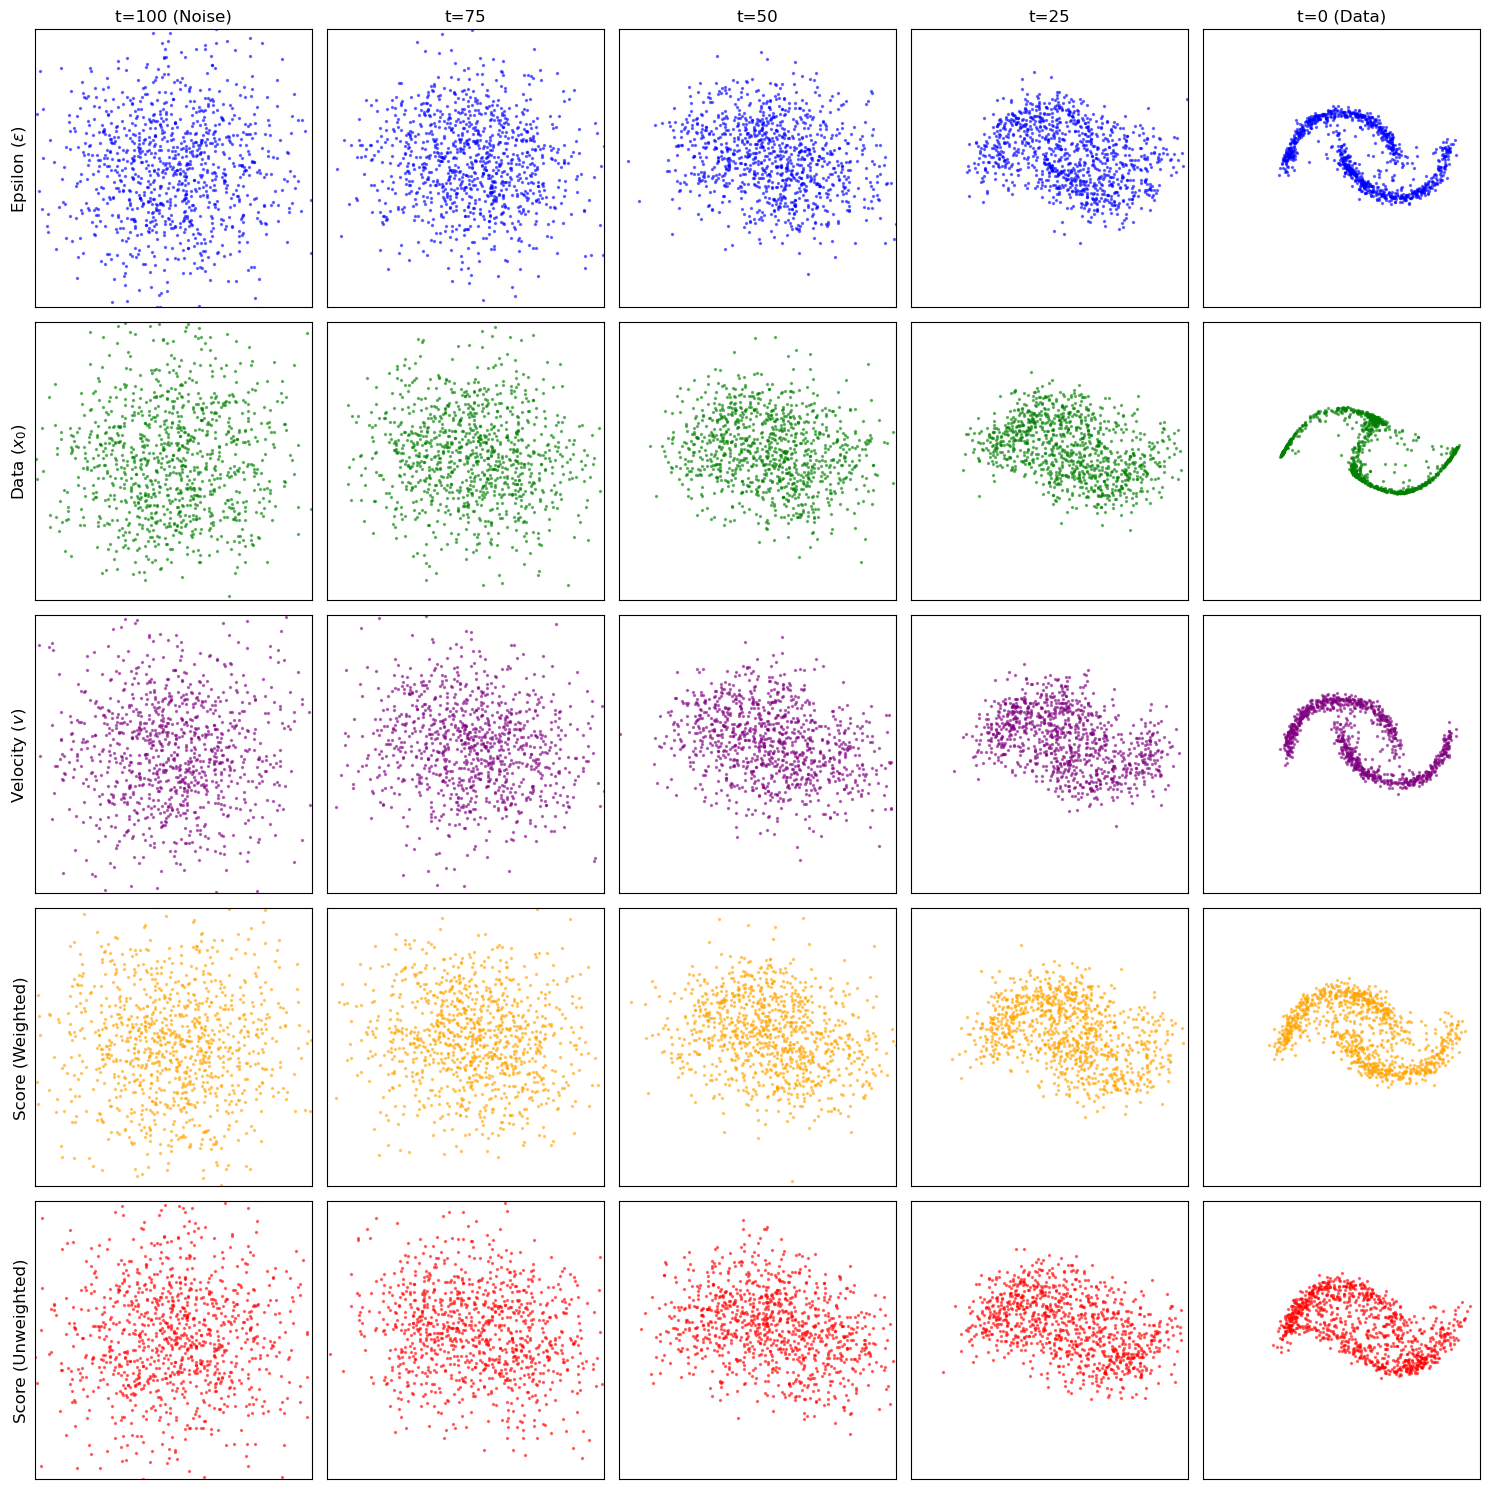

In [42]:
num_models = len(models)
fig, axes = plt.subplots(num_models, 5, figsize=(15, 3 * num_models), sharex=True, sharey=True)
titles = ["t=100 (Noise)", "t=75", "t=50", "t=25", "t=0 (Data)"]

row_labels = {
    "eps": "Epsilon ($\epsilon$)",
    "x0": "Data ($x_0$)",
    "v": "Velocity ($v$)",
    "score_weighted": "Score (Weighted)",
    "score_unweighted": "Score (Unweighted)"
}

colors = ['blue', 'green', 'purple', 'orange', 'red']

for row, (name, model) in enumerate(models.items()):
    snapshots = sample_trajectory(model, name)
    for col in range(5):
        ax = axes[row, col] if num_models > 1 else axes[col]
        pts = snapshots[col]
        ax.scatter(pts[:, 0], pts[:, 1], s=2, alpha=0.5, color=colors[row % len(colors)])
        
        if row == 0:
            ax.set_title(titles[col])
        if col == 0:
            ax.set_ylabel(row_labels[name], fontsize=12)
            
        ax.set_xlim(-2.5, 2.5)
        ax.set_ylim(-2.5, 2.5)
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.show()

### Conditional Generation on Images

Now let's move to images. We will filter MNIST to only include the digits 0, 1, and 2.

In [43]:
# Transform and load MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # Scale to [-1, 1]
])

dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# Filter for digits 0, 1, 2
idx = (dataset.targets == 0) | (dataset.targets == 1) | (dataset.targets == 2)
dataset.data = dataset.data[idx]
dataset.targets = dataset.targets[idx]

mnist_loader = DataLoader(dataset, batch_size=128, shuffle=True)
print(f"Filtered MNIST dataset size: {len(dataset)}")

Filtered MNIST dataset size: 18623


According to Bayes' rule, the conditional score is the unconditional score plus the classifier gradient. 
$$ \nabla_z \log p(z_n | y) = \nabla_z \log p(z_n) + \nabla_z \log p(y | z_n) $$

Conditional: 
$$
s_\theta(z_n, y) \approx \nabla_z \log p(z_n \mid y)
$$

Unconditional: 
$$
 s_\theta(z_n, \varnothing) \approx \nabla_z \log p(z_n)
$$

Classifier-Free Guidance (CFG) is:
$$
s_{\text{CFG}}(z_n, y) = s_\theta(z_n, \varnothing) + w \left( s_\theta(z_n, y) - s_\theta(z_n, \varnothing) \right)
$$
Since evaluating a classifier on noisy data is difficult, Classifier-Free Guidance learns both the conditional model $p(z_n|y)$ and the unconditional model $p(z_n)$ simultaneously. We achieve this by randomly dropping the label $y$ during training (replacing it with a dummy class).

In [ ]:
class ConditionalMLP(nn.Module):
    def __init__(self, num_classes=3, num_steps=100): 
        super().__init__()
        hidden_dim = 64
        
        self.time_emb = nn.Embedding(num_steps, hidden_dim)
        self.class_emb = nn.Embedding(num_classes + 1, hidden_dim)
        
        self.conv1 = nn.Conv2d(1, hidden_dim, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(hidden_dim, hidden_dim * 2, kernel_size=3, stride=2, padding=1) 
        self.conv3 = nn.ConvTranspose2d(hidden_dim * 2, hidden_dim, kernel_size=4, stride=2, padding=1) 
        
        self.fusion_conv = nn.Conv2d(hidden_dim, hidden_dim, kernel_size=3, padding=1)
        
        self.conv4 = nn.Conv2d(hidden_dim, 1, kernel_size=3, padding=1)
        
        self.emb_proj1 = nn.Linear(hidden_dim, hidden_dim)
        self.emb_proj2 = nn.Linear(hidden_dim, hidden_dim * 2)
        self.emb_proj3 = nn.Linear(hidden_dim, hidden_dim)
        
    def forward(self, x, t, labels):
        batch_size = x.shape[0]
        
        t_emb = self.time_emb(t)
        c_emb = self.class_emb(labels)
        emb = t_emb + c_emb 
        
        # Layer 1
        h1 = F.gelu(self.conv1(x))
        emb1 = self.emb_proj1(emb).view(batch_size, -1, 1, 1) 
        h1 = h1 + emb1
        
        # Layer 2
        h2 = F.gelu(self.conv2(h1))
        emb2 = self.emb_proj2(emb).view(batch_size, -1, 1, 1)
        h2 = h2 + emb2
        
        # Layer 3
        h3 = F.gelu(self.conv3(h2))
        emb3 = self.emb_proj3(emb).view(batch_size, -1, 1, 1)
        
        # Skip Connection
        h3 = h3 + h1 + emb3
        h3 = F.gelu(self.fusion_conv(h3))
        
        out = self.conv4(h3)
        return out

We drop the class label 10% of the time, replacing it with the index num_classes (which acts as our unconditional "null" token). This will take about 1.5 minutes per epoch on CPU so adjust accordingly. You may increase `hidden_dim` and/or number of epochs if you have better capacity.

In [47]:
model_mnist = ConditionalMLP(num_classes=3, num_steps=num_steps).to(device)
optimizer = torch.optim.Adam(model_mnist.parameters(), lr=5e-4)

epochs = 10
p_drop = 0.1 # Probability of dropping the label for CFG

model_mnist.train()
for epoch in range(epochs):
    epoch_loss = 0
    for x_0, labels in mnist_loader:
        x_0, labels = x_0.to(device), labels.to(device)
        batch_size = x_0.shape[0]
        
        t = torch.randint(0, num_steps, (batch_size,), device=device).long()
        noise = torch.randn_like(x_0)
        z_t = q_sample(x_0, t, noise)
        
        # CFG Dropout: Randomly replace labels with the "null" class (index 3)
        mask = torch.rand(batch_size, device=device) < p_drop
        labels[mask] = 3 
        
        noise_pred = model_mnist(z_t, t, labels)
        loss = F.mse_loss(noise_pred, noise)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        
    print(f"MNIST Epoch {epoch+1}/{epochs} | Loss: {epoch_loss/len(mnist_loader):.4f}")

MNIST Epoch 1/10 | Loss: 0.4835
MNIST Epoch 2/10 | Loss: 0.2887
MNIST Epoch 3/10 | Loss: 0.2131
MNIST Epoch 4/10 | Loss: 0.1671
MNIST Epoch 5/10 | Loss: 0.1398
MNIST Epoch 6/10 | Loss: 0.1262
MNIST Epoch 7/10 | Loss: 0.1196
MNIST Epoch 8/10 | Loss: 0.1097
MNIST Epoch 9/10 | Loss: 0.1084
MNIST Epoch 10/10 | Loss: 0.1072


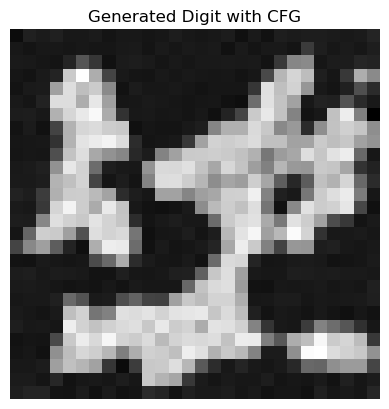

In [ ]:
@torch.no_grad()
def sample_cfg(model, target_class, guidance_scale=2.0, num_steps=100):
    model.eval()
    # Start from pure noise
    z = torch.randn(1, 1, 28, 28).to(device)
    
    # We need both the target label and the null label for CFG
    label = torch.tensor([target_class]).to(device)
    null_label = torch.tensor([3]).to(device) # 3 is our null index
    
    # Reverse diffusion process
    for i in reversed(range(num_steps)):
        t = torch.tensor([i]).to(device)
        
        # 1. Predict noise conditionally and unconditionally
        eps_cond = model(z, t, label)
        eps_uncond = model(z, t, null_label)
        
        # 2. CFG Formula: uncond + scale * (cond - uncond)
        eps_pred = eps_uncond + guidance_scale * (...) # TODO
        
        # 3. Denoising step
        alpha_t = alphas[t]
        alpha_cumprod_t = alphas_cumprod[t]
        beta_t = betas[t]
        
        if i > 0:
            noise = torch.randn_like(z)
        else:
            noise = torch.zeros_like(z) # No noise added at the very last step
            
        # Update z
        z = (1 / torch.sqrt(alpha_t)) * (z - (beta_t / torch.sqrt(1 - alpha_cumprod_t)) * eps_pred) + torch.sqrt(beta_t) * noise
        
    return z.cpu().squeeze()

# Let's sample a "2"
generated_img = sample_cfg(model_mnist, target_class=0, guidance_scale=0., num_steps=num_steps)

plt.imshow(generated_img, cmap='gray')
plt.title("Generated Digit with CFG")
plt.axis('off')
plt.show()